In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import explained_variance_score, mean_absolute_error, mean_squared_error, r2_score

### Define a function to display evaluation metrics 


In [2]:
def regression_results(y_true, y_pred, regr_type):
    ev = explained_variance_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print('Evaluation metrics for ' + regr_type + ' Linear Regression')
    print('explained_variance: ',  round(ev,4)) 
    print('r2: ', round(r2,4))
    print('MAE: ', round(mae,4))
    print('MSE: ', round(mse,4))
    print('RMSE: ', round(np.sqrt(mse),4))
    

### Generate a simple dataset with one feature


In [3]:
noise = 1
np.random.seed(42)
x = 2*np.random.randn(1000, 1)
y = 4 + 3*x + noise*np.random.randn(1000, 1)
y_ideal = 4 + 3*x

y_outlier = pd.Series(y.reshape(-1).copy())

threshold = 1.5
outlier_indices = np.where(x.flatten() > threshold)[0]

num_outlier = 5
selected_indices = np.random.choice(outlier_indices, num_outlier, replace=False)
y_outlier[selected_indices] +=  np.random.uniform(50, 100, num_outlier)

### Plot the data with outliers and the ideal fit line


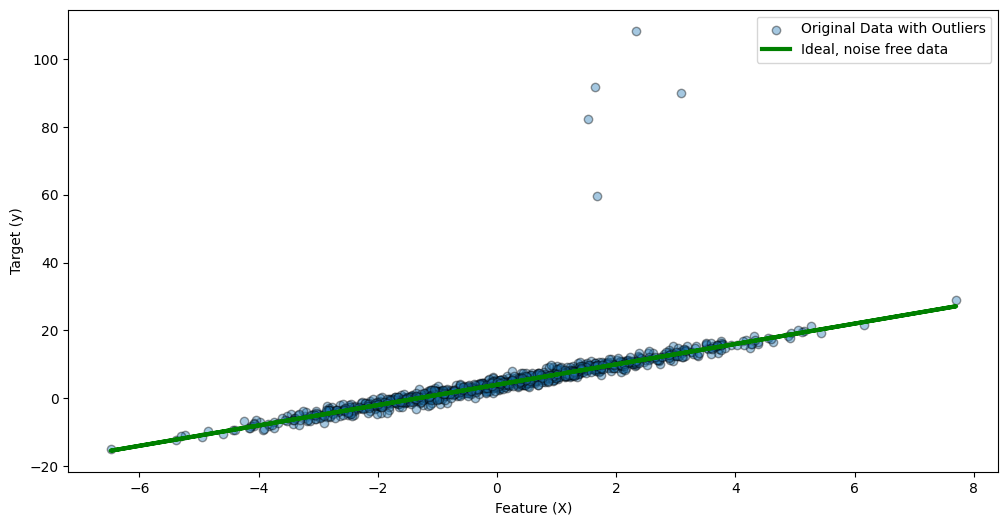

In [4]:
plt.figure(figsize=(12, 6))

# Scatter plot of the original data with outliers
plt.scatter(x, y_outlier, alpha=0.4,ec='k', label='Original Data with Outliers')
plt.plot(x, y_ideal,  linewidth=3, color='g',label='Ideal, noise free data')

plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.title('')
plt.legend()
plt.show()


### Plot the data without the outliers and the ideal fit line


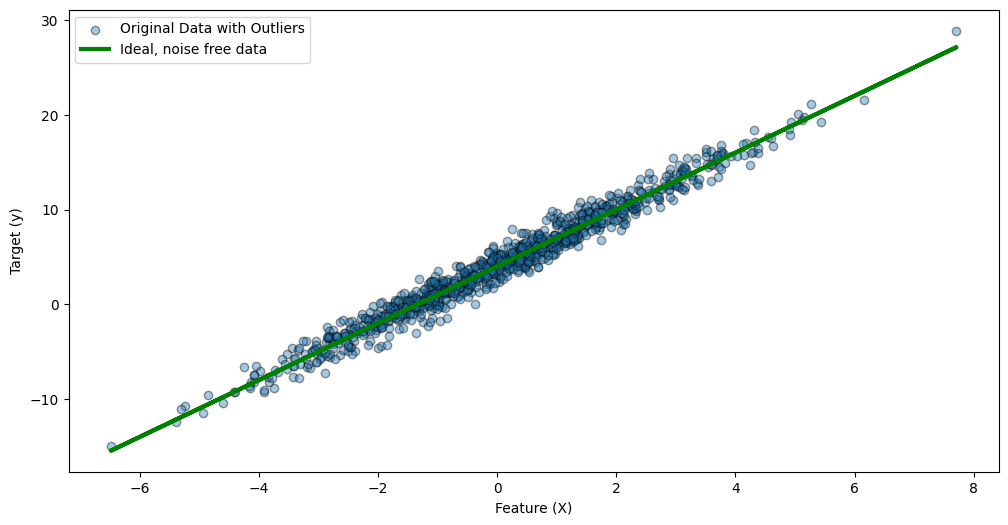

In [5]:
plt.figure(figsize=(12, 6))

# Scatter plot of the original data with outliers
plt.scatter(x, y, alpha=0.4,ec='k', label='Original Data with Outliers')
plt.plot(x, y_ideal,  linewidth=3, color='g',label='Ideal, noise free data')

plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.title('')
plt.legend()
plt.show()


### Fit Ordinary, Ridge, and Lasso regression models and use them to make predicitions on the original, outlier-free data


In [6]:
lr = LinearRegression()
lr.fit(x, y_outlier)
y_outlier_pred_lr = lr.predict(x)

ridge_reg = Ridge(alpha=1)
ridge_reg.fit(x, y_outlier)
y_outlier_pred_ridge = ridge_reg.predict(x)

lasso_reg = Lasso(alpha=.2)
lasso_reg.fit(x, y_outlier)
y_outlier_pred_lasso = lasso_reg.predict(x)

regression_results(y, y_outlier_pred_lr, 'Ordinary')
regression_results(y, y_outlier_pred_ridge, 'Ridge')
regression_results(y, y_outlier_pred_lasso, 'Lasso')

Evaluation metrics for Ordinary Linear Regression
explained_variance:  0.9671
r2:  0.9629
MAE:  0.9107
MSE:  1.2982
RMSE:  1.1394
Evaluation metrics for Ridge Linear Regression
explained_variance:  0.9671
r2:  0.963
MAE:  0.9103
MSE:  1.2969
RMSE:  1.1388
Evaluation metrics for Lasso Linear Regression
explained_variance:  0.9691
r2:  0.965
MAE:  0.8845
MSE:  1.2268
RMSE:  1.1076


### Plot the data and the predictions for comparison


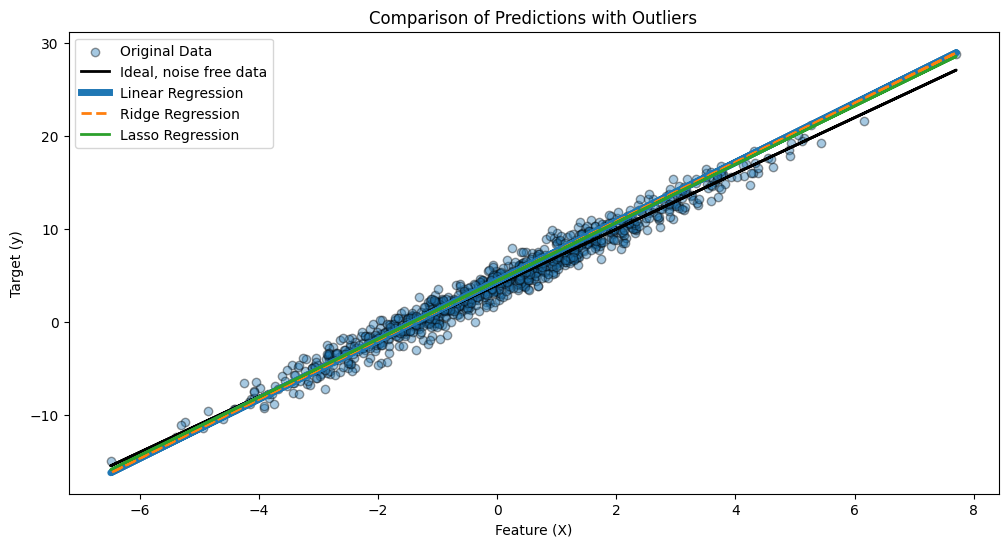

In [7]:
plt.figure(figsize=(12, 6))
plt.scatter(x, y, alpha=0.4,ec='k', label='Original Data')

plt.plot(x, y_ideal,  linewidth=2, color='k',label='Ideal, noise free data')

plt.plot(x, y_outlier_pred_lr,  linewidth=5, label='Linear Regression')

plt.plot(x, y_outlier_pred_ridge, linestyle='--', linewidth=2, label='Ridge Regression')

plt.plot(x, y_outlier_pred_lasso,  linewidth=2, label='Lasso Regression')

plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
#plt.ylim((0,20))
plt.title('Comparison of predictions with no outliers')
plt.title('Comparison of Predictions with Outliers')
plt.legend()
plt.show()

## Multiple regression regularization and Lasso feature selction


### Create a high dimensional synthetic dataset with a small number of informative features using `make_regression`


In [9]:
from sklearn.datasets import make_regression

x, y, ideal_coef = make_regression(n_samples=100, n_features=100, n_informative=10, noise=10, random_state=42, coef=True)

ideal_predictions = x @ ideal_coef

x_train, x_test, y_train, y_test, ideal_train, ideal_test = train_test_split(x, y, ideal_predictions, test_size=0.3, random_state=42)

### Initialize and fit the linear regression models and use them to predict the target.


In [12]:
lasso = Lasso(alpha=0.1)
ridge = Ridge(alpha=1.0)
linear = LinearRegression()

# Fit the models
lasso.fit(x_train, y_train)
ridge.fit(x_train, y_train)
linear.fit(x_train, y_train)

# Predict on the test set
y_pred_linear = linear.predict(x_test)
y_pred_ridge = ridge.predict(x_test)
y_pred_lasso = lasso.predict(x_test)

regression_results(y_test, y_pred_linear, 'Ordinary')
regression_results(y_test, y_pred_ridge, 'Ridge')
regression_results(y_test, y_pred_lasso, 'Lasso')

Evaluation metrics for Ordinary Linear Regression
explained_variance:  0.4354
r2:  0.4018
MAE:  77.7353
MSE:  9844.2714
RMSE:  99.2183
Evaluation metrics for Ridge Linear Regression
explained_variance:  0.4446
r2:  0.4079
MAE:  76.9622
MSE:  9744.4693
RMSE:  98.7141
Evaluation metrics for Lasso Linear Regression
explained_variance:  0.9815
r2:  0.9815
MAE:  13.8855
MSE:  304.644
RMSE:  17.4541


### Plot the predictions vs actuals 


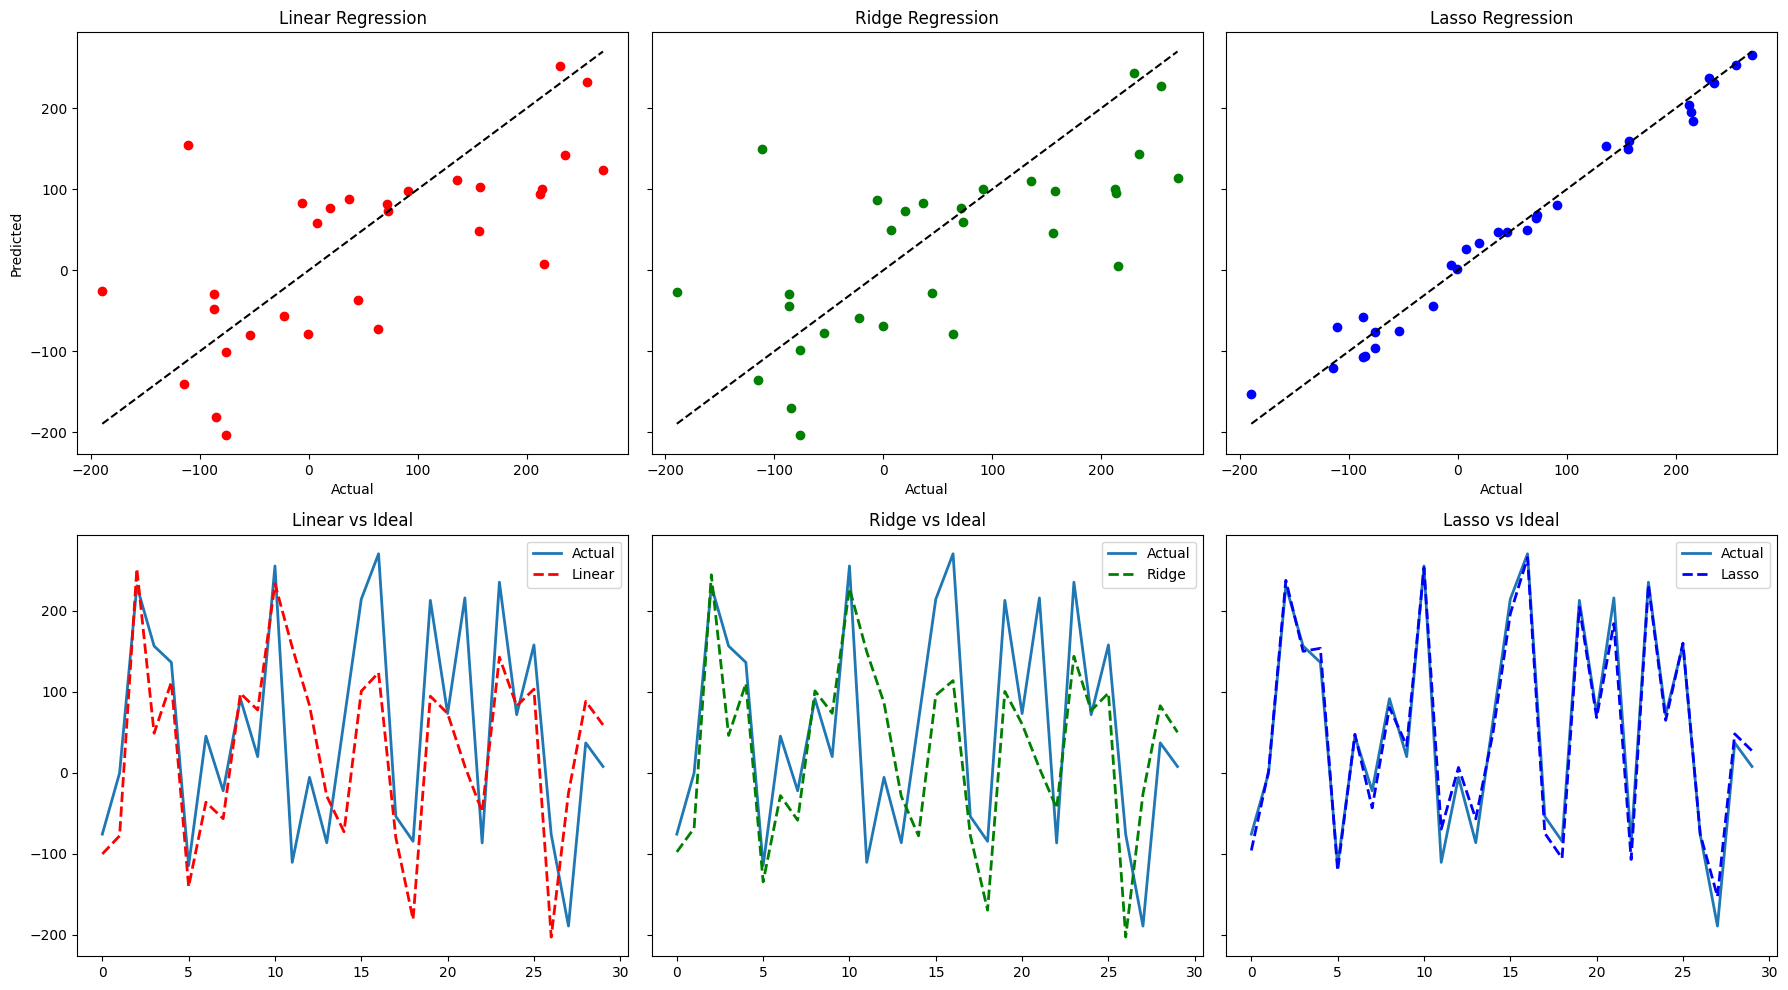

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)

axes[0,0].scatter(y_test, y_pred_linear, color="red", label="Linear")
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[0,0].set_title("Linear Regression")
axes[0,0].set_xlabel("Actual",)
axes[0,0].set_ylabel("Predicted",)

axes[0,2].scatter(y_test, y_pred_lasso, color="blue", label="Lasso")
axes[0,2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[0,2].set_title("Lasso Regression",)
axes[0,2].set_xlabel("Actual",)

axes[0,1].scatter(y_test, y_pred_ridge, color="green", label="Ridge")
axes[0,1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[0,1].set_title("Ridge Regression",)
axes[0,1].set_xlabel("Actual",)


# Line plots for predictions compared to actual and ideal predictions
axes[1,0].plot(y_test, label="Actual", lw=2)
axes[1,0].plot(y_pred_linear, '--', lw=2, color='red', label="Linear")
axes[1,0].set_title("Linear vs Ideal",)
axes[1,0].legend()
 
axes[1,1].plot(y_test, label="Actual", lw=2)
# axes[1,1].plot(ideal_test, '--', label="Ideal", lw=2, color="purple")
axes[1,1].plot(y_pred_ridge, '--', lw=2, color='green', label="Ridge")
axes[1,1].set_title("Ridge vs Ideal",)
axes[1,1].legend()
 
axes[1,2].plot(y_test, label="Actual", lw=2)
axes[1,2].plot(y_pred_lasso, '--', lw=2, color='blue', label="Lasso")
axes[1,2].set_title("Lasso vs Ideal",)
axes[1,2].legend()
 
plt.tight_layout()
plt.show()

### Model coefficients


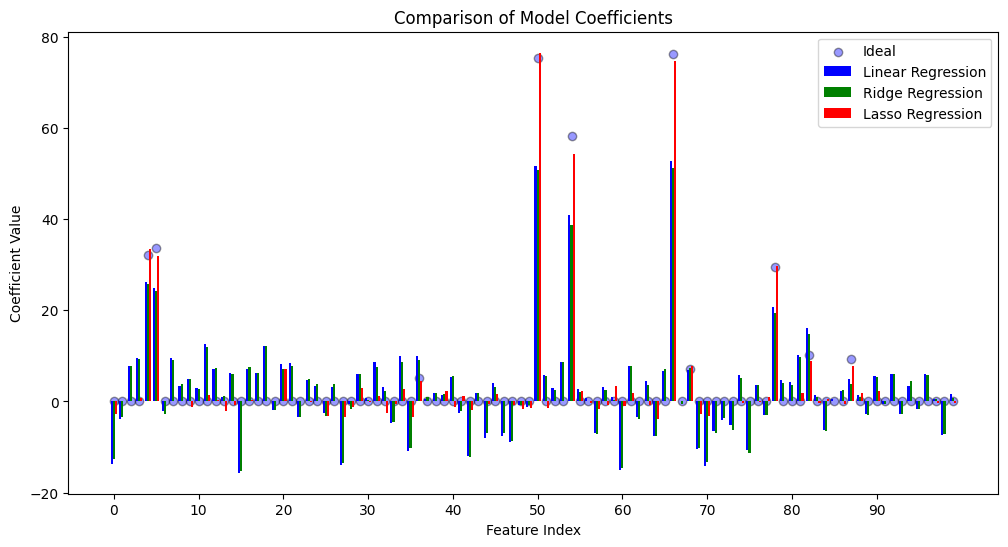

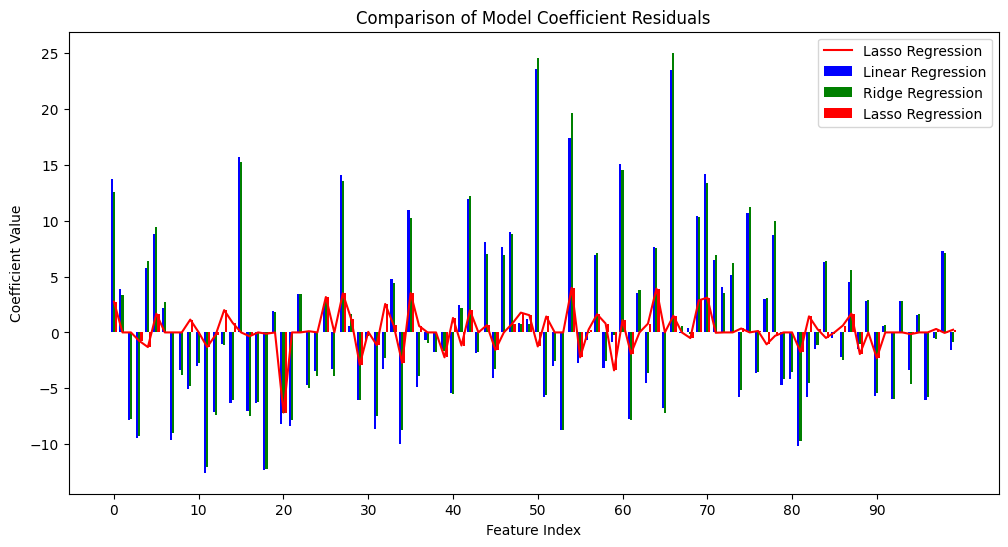

In [17]:
# Model coefficients
linear_coeff = linear.coef_
ridge_coeff = ridge.coef_
lasso_coeff = lasso.coef_


# Plot the coefficients
x_axis = np.arange(len(linear_coeff))
x_labels = np.arange(min(x_axis),max(x_axis),10)
plt.figure(figsize=(12, 6))

plt.scatter(x_axis, ideal_coef,  label='Ideal', color='blue', ec='k', alpha=0.4)
plt.bar(x_axis - 0.25, linear_coeff, width=0.25, label='Linear Regression', color='blue')
plt.bar(x_axis, ridge_coeff, width=0.25, label='Ridge Regression', color='green')
plt.bar(x_axis + 0.25, lasso_coeff, width=0.25, label='Lasso Regression', color='red')

plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.title('Comparison of Model Coefficients')
plt.xticks(x_labels)
plt.legend()
plt.show()


# Plot the coefficient residuals
x_axis = np.arange(len(linear_coeff))

plt.figure(figsize=(12, 6))

plt.bar(x_axis - 0.25, ideal_coef - linear_coeff, width=0.25, label='Linear Regression', color='blue')
plt.bar(x_axis, ideal_coef - ridge_coeff, width=0.25, label='Ridge Regression', color='green')
plt.bar(x_axis + 0.25, ideal_coef - lasso_coeff, width=0.25, label='Lasso Regression', color='red')
plt.plot(x_axis, ideal_coef - lasso_coeff, label='Lasso Regression', color='red')

plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.title('Comparison of Model Coefficient Residuals')
plt.xticks(x_labels)
plt.legend()
plt.show()

### Use Lasso to select the most important features and compare the three different linear regression models again on the resulting data.


#### Part 1. Choose a threshold value to select features based on the Lasso model coefficients


In [18]:
threshold = 5 
feature_importance_df = pd.DataFrame({
    'Lasso Coefficient': lasso_coeff,
    'Ideal Coefficient': ideal_coef
})
feature_importance_df['Feature Selected'] = feature_importance_df['Lasso Coefficient'].abs() > threshold


print("Features Identified as Important by Lasso:")
display(feature_importance_df[feature_importance_df['Feature Selected']])

print("\nNonzero Ideal Coefficient Indices")
display(feature_importance_df[feature_importance_df['Ideal Coefficient']>0])



Features Identified as Important by Lasso:


,Lasso Coefficient,Ideal Coefficient,Feature Selected
4,33.435088,32.125517,True
5,32.014793,33.692687,True
20,7.163636,0.000000,True
50,76.576829,75.319970,True
54,54.306360,58.286936,True
66,74.841971,76.330808,True
68,7.685653,7.180755,True
78,29.735685,29.434817,True
82,8.864669,10.301919,True
87,7.745131,9.427598,True



Nonzero Ideal Coefficient Indices


,Lasso Coefficient,Ideal Coefficient,Feature Selected
4,33.435088,32.125517,True
5,32.014793,33.692687,True
36,4.588118,5.166218,False
50,76.576829,75.319970,True
54,54.306360,58.286936,True
66,74.841971,76.330808,True
68,7.685653,7.180755,True
78,29.735685,29.434817,True
82,8.864669,10.301919,True
87,7.745131,9.427598,True


#### Part 2. Use the threshold to select the most important features for use in modelling.


In [20]:
important_features = feature_importance_df[feature_importance_df['Feature Selected']].index

X_filtered = x[:, important_features]
print("Shape of the filtered feature set:", X_filtered.shape)

X_train, X_test, y_train, y_test, ideal_train, ideal_test = train_test_split(X_filtered, y, ideal_predictions, test_size=0.3, random_state=42)

Shape of the filtered feature set: (100, 10)


#### Part 3. Fit and apply the three models to the selected features


In [21]:
# Initialize the models
lasso = Lasso(alpha=0.1)
ridge = Ridge(alpha=1.0)
linear = LinearRegression()

# Fit the models
lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)
linear.fit(X_train, y_train)

# Predict on the test set
y_pred_linear = linear.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

regression_results(y_test, y_pred_linear, 'Ordinary')
regression_results(y_test, y_pred_ridge, 'Ridge')
regression_results(y_test, y_pred_lasso, 'Lasso')


Evaluation metrics for Ordinary Linear Regression
explained_variance:  0.9917
r2:  0.9915
MAE:  9.653
MSE:  139.4874
RMSE:  11.8105
Evaluation metrics for Ridge Linear Regression
explained_variance:  0.9909
r2:  0.9905
MAE:  10.1418
MSE:  156.9035
RMSE:  12.5261
Evaluation metrics for Lasso Linear Regression
explained_variance:  0.9917
r2:  0.9914
MAE:  9.6928
MSE:  140.803
RMSE:  11.866
